# Cuaderno 4: Muestreo y cuantización

Este cuaderno se concentra en dos preguntas importantes:

- ¿qué pasa cuando una imagen tiene menos muestras espaciales?
- ¿qué pasa cuando una imagen tiene menos niveles de intensidad?

Responder esas preguntas ayuda a entender cómo una imagen digital pierde o conserva información.

## Objetivos

- Analizar una imagen como matriz de intensidades.
- Reducir la resolución espacial por muestreo.
- Implementar un histograma manual simple.
- Reducir niveles de gris por cuantización.
- Comparar visualmente y numéricamente los resultados.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski


def analizar_imagen(imagen, nombre="Imagen"):
    print(nombre)
    print(f"  forma: {imagen.shape}")
    print(f"  tipo de dato: {imagen.dtype}")
    print(f"  mínimo: {imagen.min()}")
    print(f"  máximo: {imagen.max()}")
    print(f"  rango dinámico: {imagen.max() - imagen.min()}")


def calcular_histograma_manual(imagen, n_bins=256):
    hist = np.zeros(n_bins, dtype=int)
    filas, columnas = imagen.shape

    for i in range(filas):
        for j in range(columnas):
            hist[imagen[i, j]] += 1

    return hist


Imagen original
  forma: (512, 512)
  tipo de dato: uint8
  mínimo: 0
  máximo: 255
  rango dinámico: 255


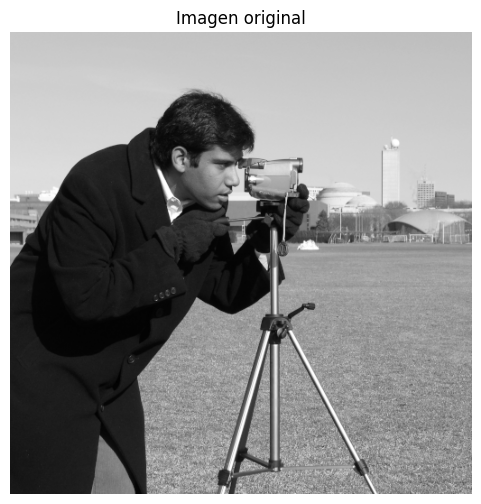

In [2]:
imagen = ski.data.camera()

analizar_imagen(imagen, "Imagen original")

plt.figure(figsize=(6, 6))
plt.imshow(imagen, cmap="gray", vmin=0, vmax=255)
plt.title("Imagen original")
plt.axis("off")
plt.show()


## 1. Muestreo espacial

El muestreo espacial indica cuántos píxeles usamos para representar la imagen. Si tomamos menos muestras, la imagen conserva la estructura general, pero pierde detalle fino.


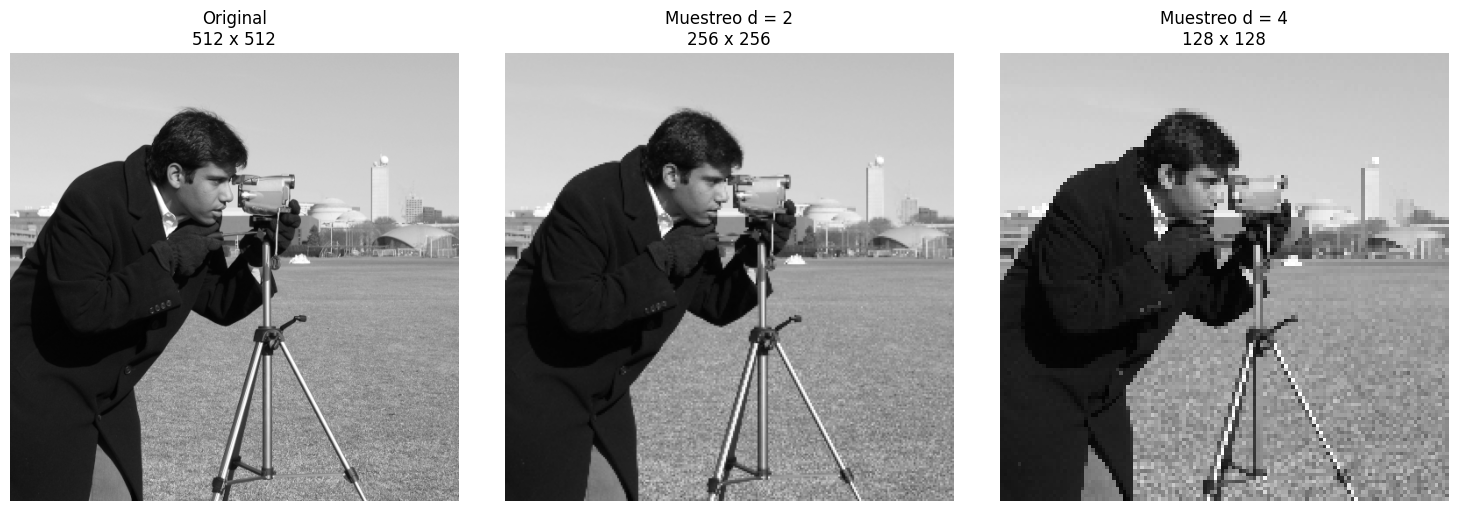

In [4]:
paso_2 = imagen[::2, ::2]
paso_4 = imagen[::4, ::4]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imagen, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Original\n{imagen.shape[0]} x {imagen.shape[1]}")
axes[0].axis("off")

axes[1].imshow(paso_2, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Muestreo d = 2\n{paso_2.shape[0]} x {paso_2.shape[1]}")
axes[1].axis("off")

axes[2].imshow(paso_4, cmap="gray", vmin=0, vmax=255)
axes[2].set_title(f"Muestreo d = 4\n{paso_4.shape[0]} x {paso_4.shape[1]}")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Pregunta guía

Observá las tres imágenes y pensá:

- ¿qué detalles desaparecen primero?
- ¿la pérdida de información afecta del mismo modo a toda la imagen?
- ¿en qué situaciones convendría aceptar esa pérdida?


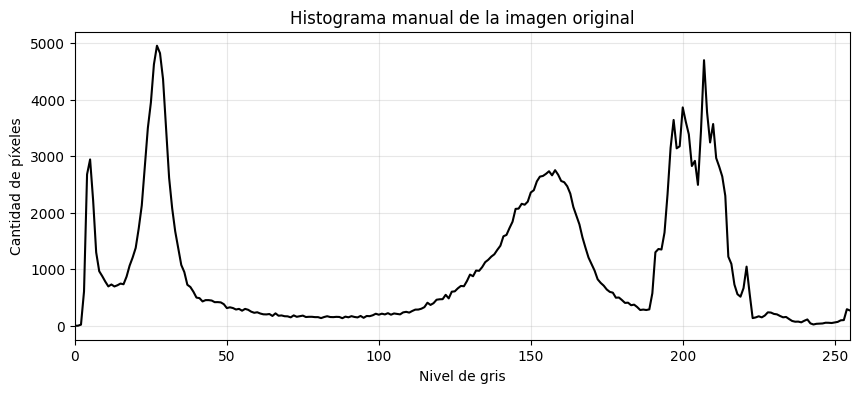

In [5]:
hist_original = calcular_histograma_manual(imagen)

plt.figure(figsize=(10, 4))
plt.plot(hist_original, color="black", linewidth=1.5)
plt.title("Histograma manual de la imagen original")
plt.xlabel("Nivel de gris")
plt.ylabel("Cantidad de píxeles")
plt.grid(alpha=0.3)
plt.xlim(0, 255)
plt.show()


## 2. Cuantización

La cuantización reduce la cantidad de niveles de gris disponibles. La imagen conserva su forma general, pero los cambios suaves de intensidad se vuelven más bruscos.


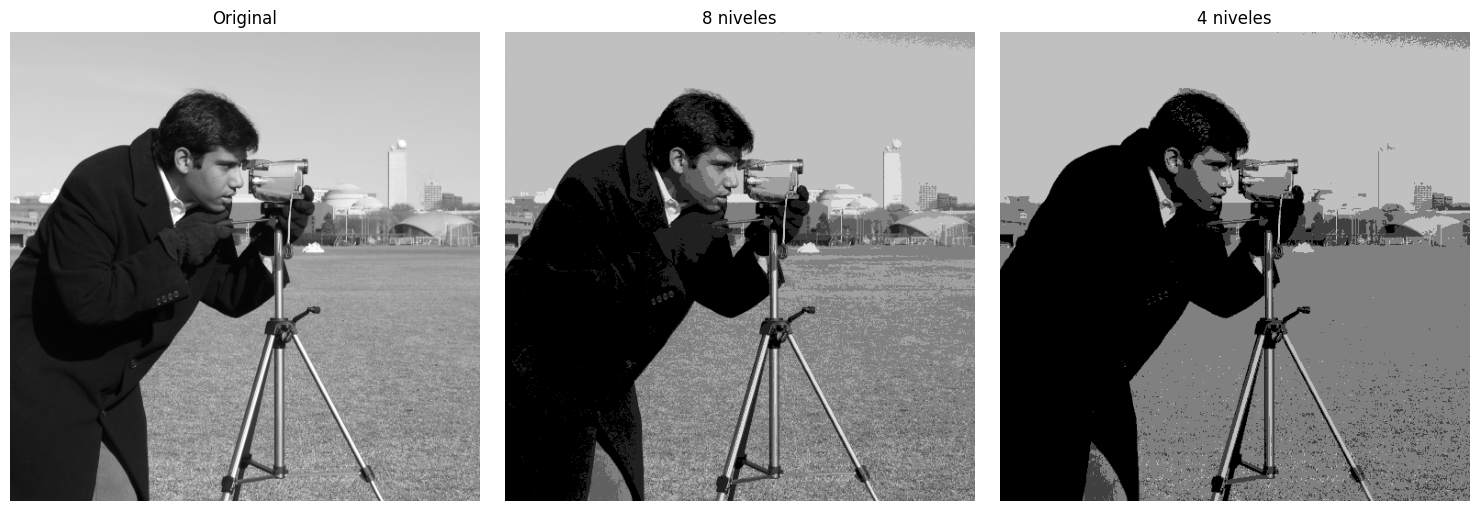

In [6]:
def cuantizar(imagen, niveles):
    paso = 256 // niveles
    return (imagen // paso) * paso


cuant_8 = cuantizar(imagen, 8)
cuant_4 = cuantizar(imagen, 4)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imagen, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cuant_8, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("8 niveles")
axes[1].axis("off")

axes[2].imshow(cuant_4, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("4 niveles")
axes[2].axis("off")

plt.tight_layout()
plt.show()


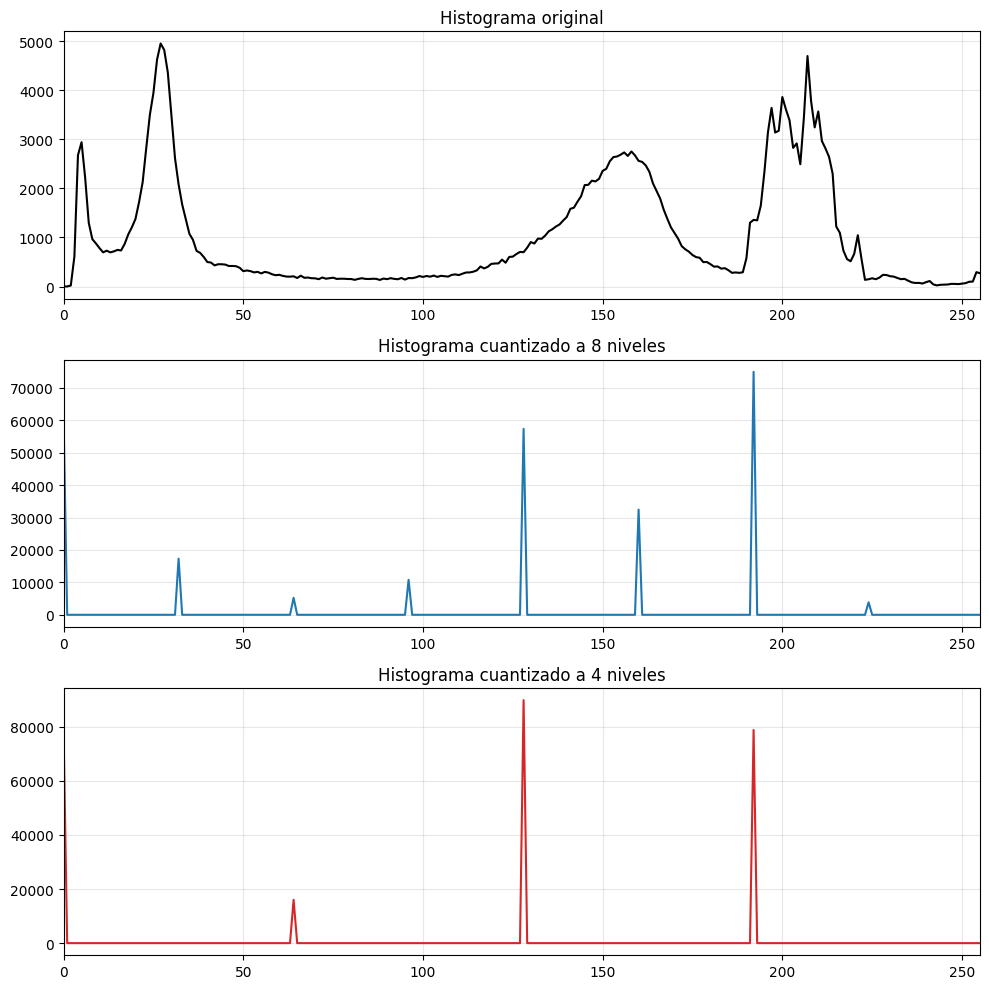

In [7]:
hist_cuant_8 = calcular_histograma_manual(cuant_8)
hist_cuant_4 = calcular_histograma_manual(cuant_4)

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

axes[0].plot(hist_original, color="black")
axes[0].set_title("Histograma original")
axes[0].set_xlim(0, 255)
axes[0].grid(alpha=0.3)

axes[1].plot(hist_cuant_8, color="tab:blue")
axes[1].set_title("Histograma cuantizado a 8 niveles")
axes[1].set_xlim(0, 255)
axes[1].grid(alpha=0.3)

axes[2].plot(hist_cuant_4, color="tab:red")
axes[2].set_title("Histograma cuantizado a 4 niveles")
axes[2].set_xlim(0, 255)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Cierre

Muestrear y cuantizar no significan lo mismo:

- el muestreo modifica la cantidad de información espacial;
- la cuantización modifica la cantidad de niveles posibles.

En ambos casos hay pérdida de información, pero esa pérdida no afecta del mismo modo a la imagen. Entender esa diferencia es clave para leer, comprimir, segmentar y analizar imágenes digitales.
